This notebook is meant to demonstrate how to use the Gatheral SVI skew fit. The example creates a volatility smile from NVDA option data. The SVI parameters are then optimized to fit the implied volatilties. The resulting fits for puts looks reasonable, but the call shows some strange behavior near at the money strikes. 

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from impliedvolatility import impliedvol_bisection
from gatheral import fit_svi, svi_volatility

In [21]:
# load the NVDA options data
data = pd.read_csv("data.csv")
data.head()

,Strike,Price,Type
0,5,178.10,Call
1,10,173.72,Call
2,15,176.91,Call
3,20,161.09,Call
4,25,155.47,Call


In [22]:
# market parameters for NVDA options
S = 180      # current NVDA price (approx)
r = 0.04     # risk-free rate
T = 0.866    # time to expiration (Jan 2027)

In [23]:
# compute implied volatility for each option
# deep in the money or out of the money options may return NaN if method fails to converge
def compute_iv(row):
    K = row["Strike"]
    price = row["Price"]
    opt_type = row["Type"].lower()
    return impliedvol_bisection(S, K, r, T, price, opt_type)

data["IV"] = data.apply(compute_iv, axis=1)

# drop rows where IV could not be computed 
data = data.dropna(subset = ["IV"])

data.head()

bisection failed too many iterations
bisection failed too many iterations
bisection failed too many iterations


,Strike,Price,Type,IV
0,5,178.10,Call,3.573964
1,10,173.72,Call,2.585607
2,15,176.91,Call,3.866278
3,20,161.09,Call,1.163517
5,30,153.70,Call,1.364721


In [24]:
# separate calls and puts
calls = data[data["Type"] == "Call"].copy()
puts  = data[data["Type"] == "Put"].copy()

In [25]:
# fit the gatheral svi model to the call implied volatility skew
call_params = fit_svi(
    strikes = calls["Strike"].values,
    implied_vols = calls["IV"].values,
    T = T,
    S = S
)

print("SVI parameters (calls): a = {:.4f}, b = {:.4f}, rho = {:.4f}, m = {:.4f}, sigma = {:.4f}".format(*call_params))

SVI parameters (calls): a = -50.9071, b = 18.0071, rho = 0.6174, m = 2.9071, sigma = 3.5836


In [26]:
# fit the Gatheral SVI model to the put implied volatility skew
put_params = fit_svi(
    strikes = puts["Strike"].values,
    implied_vols = puts["IV"].values,
    T = T,
    S = S
)

print("SVI parameters (puts):  a = {:.4f}, b = {:.4f}, rho = {:.4f}, m = {:.4f}, sigma = {:.4f}".format(*put_params))

SVI parameters (puts):  a = -2.6809, b = 1.1590, rho = 0.4254, m = 1.1459, sigma = 2.7542


c:\docker\fm5252\project3\gatheral.py:56: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(w / T)


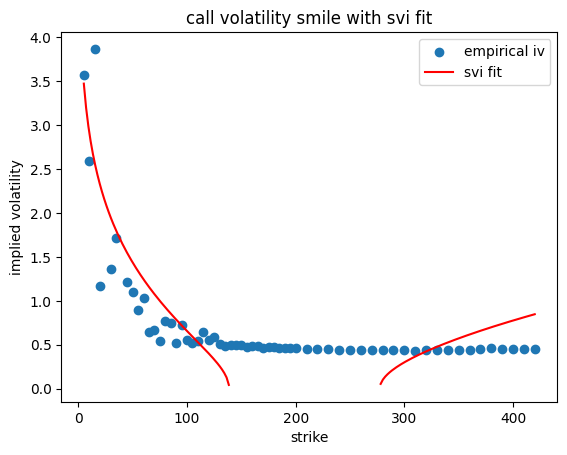

In [27]:
# plot the empirical call IV alongside the SVI fitted curve
strike_grid = np.linspace(calls["Strike"].min(), calls["Strike"].max(), 200)
svi_call_vols = [svi_volatility(k, call_params, T, S) for k in strike_grid]

plt.figure()
plt.scatter(calls["Strike"], calls["IV"], label = "empirical iv")
plt.plot(strike_grid, svi_call_vols, color = "red", label = "svi fit")
plt.xlabel("strike")
plt.ylabel("implied volatility")
plt.title("call volatility smile with svi fit")
plt.legend()
plt.show()

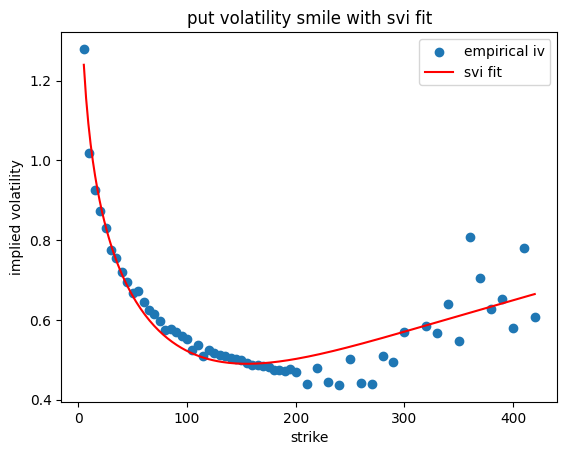

In [28]:
# plot the empirical put IV alongside the SVI fitted curve
strike_grid = np.linspace(puts["Strike"].min(), puts["Strike"].max(), 200)
svi_put_vols = [svi_volatility(k, put_params, T, S) for k in strike_grid]

plt.figure()
plt.scatter(puts["Strike"], puts["IV"], label = "empirical iv")
plt.plot(strike_grid, svi_put_vols, color = "red", label = "svi fit")
plt.xlabel("strike")
plt.ylabel("implied volatility")
plt.title("put volatility smile with svi fit")
plt.legend()
plt.show()